X_raw shape: (450, 2)
y_raw shape: (450,)


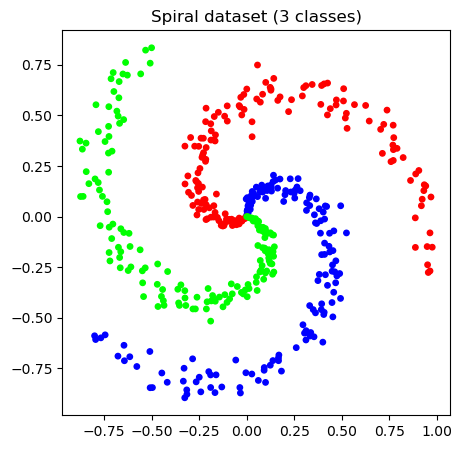

X: (2, 450)  Y: (3, 450)
iter    0  loss = 1.0837
iter  200  loss = 0.0470
iter  400  loss = 0.0595
iter  600  loss = 0.0337
iter  800  loss = 0.0365
iter 1000  loss = 0.0241
iter 1200  loss = 0.0219
iter 1400  loss = 0.0213
iter 1600  loss = 0.0208
iter 1800  loss = 0.0226
iter 2000  loss = 0.0274
iter 2200  loss = 0.0187
iter 2400  loss = 0.0143
iter 2600  loss = 0.0161
iter 2800  loss = 0.0154
iter 2999  loss = 0.0143


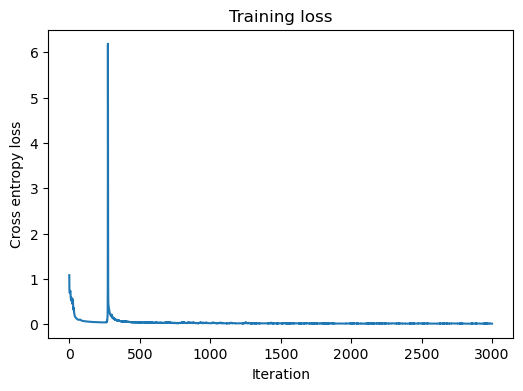

Training accuracy: 99.56%


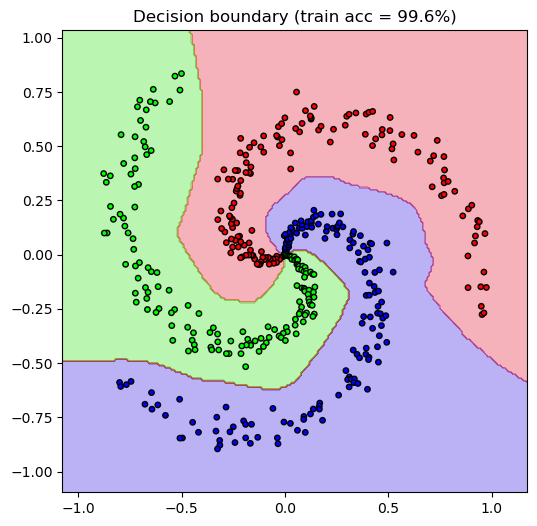

In [12]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def make_spiral(points_per_class=150, num_classes=3):
    N = points_per_class
    K = num_classes
    X = np.zeros((N * K, 2))
    y = np.zeros(N * K, dtype='uint8')

    for k in range(K):
        ix = range(N * k, N * (k + 1))
        r = np.linspace(0.0, 1, N)                      # radius
        t = np.linspace(k * 4, (k + 1) * 4, N) + np.random.randn(N) * 0.2  # angle + noise
        X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
        y[ix] = k

    return X, y

X_raw, y_raw = make_spiral()
print("X_raw shape:", X_raw.shape)
print("y_raw shape:", y_raw.shape)

plt.figure(figsize=(5, 5))
plt.scatter(X_raw[:, 0], X_raw[:, 1], c=y_raw, cmap='brg', s=15)
plt.title("Spiral dataset (3 classes)")
plt.show()


# reshape into our (features, examples) convention and one-hot the labels
X = X_raw.T                       # shape (2, m)
m = X.shape[1]
num_classes = 3

Y = np.zeros((num_classes, m))
Y[y_raw, np.arange(m)] = 1        # one-hot, shape (num_classes, m)

print("X:", X.shape, " Y:", Y.shape)


def init_params(layer_dims):
    np.random.seed(1)
    params = {}
    L = len(layer_dims) - 1  # number of layers with weights

    for l in range(1, L + 1):
        params['W' + str(l)] = np.random.randn(layer_dims[l], layer_dims[l - 1]) * np.sqrt(2.0 / layer_dims[l - 1])
        params['b' + str(l)] = np.zeros((layer_dims[l], 1))

    return params

def relu(Z):
    return np.maximum(0, Z)

def relu_backward(Z):
    # derivative of relu is 1 where Z>0, 0 elsewhere
    return (Z > 0).astype(float)

def softmax(Z):
    # subtract max for numerical stability (standard trick, avoids overflow)
    Z_shift = Z - np.max(Z, axis=0, keepdims=True)
    exp_Z = np.exp(Z_shift)
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)


def forward_pass(X, params, L):
    cache = {'A0': X}
    A = X

    for l in range(1, L + 1):
        W = params['W' + str(l)]
        b = params['b' + str(l)]
        Z = W.dot(A) + b

        if l == L:
            A = softmax(Z)          # output layer
        else:
            A = relu(Z)             # hidden layer

        cache['Z' + str(l)] = Z
        cache['A' + str(l)] = A

    return A, cache

def compute_loss(A_out, Y):
    m = Y.shape[1]
    eps = 1e-8
    loss = -np.sum(Y * np.log(A_out + eps)) / m
    return loss


def backward_pass(Y, params, cache, L):
    grads = {}
    m = Y.shape[1]

    # ---- output layer ----
    A_out = cache['A' + str(L)]
    dZ = A_out - Y   # combined softmax + cross-entropy gradient

    for l in range(L, 0, -1):
        A_prev = cache['A' + str(l - 1)]
        W = params['W' + str(l)]

        dW = dZ.dot(A_prev.T) / m
        db = np.sum(dZ, axis=1, keepdims=True) / m

        grads['dW' + str(l)] = dW
        grads['db' + str(l)] = db

        if l > 1:
            dA_prev = W.T.dot(dZ)
            Z_prev = cache['Z' + str(l - 1)]
            dZ = dA_prev * relu_backward(Z_prev)   # move into layer l-1

    return grads


def update_params(params, grads, L, learning_rate):
    for l in range(1, L + 1):
        params['W' + str(l)] -= learning_rate * grads['dW' + str(l)]
        params['b' + str(l)] -= learning_rate * grads['db' + str(l)]
    return params


def train(X, Y, layer_dims, learning_rate=0.5, num_iters=3000, print_every=200):
    L = len(layer_dims) - 1
    params = init_params(layer_dims)
    loss_history = []

    for i in range(num_iters):
        A_out, cache = forward_pass(X, params, L)
        loss = compute_loss(A_out, Y)
        grads = backward_pass(Y, params, cache, L)
        params = update_params(params, grads, L, learning_rate)

        loss_history.append(loss)
        if i % print_every == 0 or i == num_iters - 1:
            print(f"iter {i:4d}  loss = {loss:.4f}")

    return params, loss_history


layer_dims = [2, 64, 32, num_classes]   # 2 hidden layers: 64 units, 32 units

params, loss_history = train(X, Y, layer_dims, learning_rate=1.0, num_iters=3000, print_every=200)


plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Cross entropy loss")
plt.title("Training loss")
plt.show()


def predict(X, params, L):
    A_out, _ = forward_pass(X, params, L)
    return np.argmax(A_out, axis=0)

L = len(layer_dims) - 1
preds = predict(X, params, L)
accuracy = np.mean(preds == y_raw)
print(f"Training accuracy: {accuracy * 100:.2f}%")


h = 0.01
x_min, x_max = X_raw[:, 0].min() - 0.2, X_raw[:, 0].max() + 0.2
y_min, y_max = X_raw[:, 1].min() - 0.2, X_raw[:, 1].max() + 0.2
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

grid = np.c_[xx.ravel(), yy.ravel()].T   # shape (2, N)
grid_preds = predict(grid, params, L)
grid_preds = grid_preds.reshape(xx.shape)

plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, grid_preds, cmap='brg', alpha=0.3)
plt.scatter(X_raw[:, 0], X_raw[:, 1], c=y_raw, cmap='brg', s=15, edgecolors='k')
plt.title(f"Decision boundary (train acc = {accuracy*100:.1f}%)")
plt.show()